# Datathon ESAN 2026 - FinanCrece S.A.

## Notebook final de entrega

**Objetivo oficial:** construir una herramienta que reciba caracteristicas de un solicitante, estime la probabilidad de incumplimiento (`prob_default`) y determine si el perfil es adecuado para aprobar el prestamo dentro de la politica de riesgo de la institucion financiera.

Este notebook ejecuta el flujo completo: carga de datos, EDA, feature engineering, comparacion de modelos, seleccion auditora del campeon, politica de 3 bandas, simulacion financiera, herramienta de scoring y `submission.csv`.


## 0. Enfoque metodologico

Usamos un enfoque de scoring crediticio bancario:

- Target canónico: `default_90d`, derivado de `target`: `bad=1`, `good=0`.
- Separacion anti-leakage: ninguna imputacion, escalado ni one-hot se ajusta antes del split.
- Metricas de riesgo: ROC-AUC, Gini, KS, Brier, PR-AUC y Lift@10.
- Decision de negocio: `prob_default` se transforma en politica de 3 bandas.
- ROI: se usa la matriz economica documentada del caso/supuestos.

Nota: el Excel oficial no contiene `score_buro`, `ingreso_mensual`, `zona_geografica` ni `canal_captacion`; no se inventan variables.


In [1]:
from pathlib import Path
from copy import deepcopy
import json
import sys
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

PROJECT_ROOT = Path(".")
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(SRC_DIR.resolve()))

import flujo_orquestador_final as flow
from feature_builder import build_features_german
from herramienta_scoring import score as score_app

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
print("Notebook listo. Ruta:", PROJECT_ROOT.resolve())

Notebook listo. Ruta: C:\Cursos\Datathon


## 1. Carga del caso oficial y definicion del target

In [2]:
df_train = pd.read_excel("dataInicial/dataset_credito-train.xlsx", engine="openpyxl")
df_test = pd.read_excel("dataInicial/dataset_credito-test.xlsx", engine="openpyxl")

df_train["default_90d"] = (df_train["target"] == "bad").astype(int)

target_summary = pd.DataFrame({
    "clase": ["good / pagador", "bad / default"],
    "valor_default_90d": [0, 1],
    "clientes": [
        int((df_train["default_90d"] == 0).sum()),
        int((df_train["default_90d"] == 1).sum()),
    ],
})
target_summary["porcentaje"] = target_summary["clientes"] / len(df_train)

print(f"Train oficial: {df_train.shape[0]} filas x {df_train.shape[1]} columnas")
print(f"Test oficial:  {df_test.shape[0]} filas x {df_test.shape[1]} columnas")
print(f"Tasa default train: {df_train['default_90d'].mean():.2%}")
display(target_summary)

Train oficial: 800 filas x 23 columnas
Test oficial:  200 filas x 23 columnas
Tasa default train: 29.50%


,clase,valor_default_90d,clientes,porcentaje
0,good / pagador,0,564,0.7050
1,bad / default,1,236,0.2950


## 2. Calidad de datos y EDA de riesgo

In [3]:
quality = pd.DataFrame({
    "dataset": ["train", "test"],
    "filas": [len(df_train), len(df_test)],
    "columnas": [df_train.shape[1], df_test.shape[1]],
    "nulos_sin_placeholder": [
        int(df_train.isna().sum().sum()),
        int(df_test.drop(columns=["Probabilidad"], errors="ignore").isna().sum().sum()),
    ],
    "duplicados_id_cliente": [
        int(df_train["id_cliente"].duplicated().sum()),
        int(df_test["id_cliente"].duplicated().sum()),
    ],
})
display(quality)

cat_vars = ["checking_status", "credit_history", "savings_status", "employment", "purpose", "housing"]
eda_tables = {}
for col in cat_vars:
    table = (
        df_train.groupby(col)["default_90d"]
        .agg(default_rate="mean", n="count")
        .sort_values("default_rate", ascending=False)
    )
    eda_tables[col] = table

print("Default rate por checking_status")
display(eda_tables["checking_status"])
print("Default rate por credit_history")
display(eda_tables["credit_history"])

num_cols = ["duration", "credit_amount", "installment_commitment", "residence_since", "age", "existing_credits", "num_dependents"]
num_corr = df_train[num_cols + ["default_90d"]].corr()["default_90d"].drop("default_90d")
num_corr = num_corr.reindex(num_corr.abs().sort_values(ascending=False).index).to_frame("corr_default")
display(num_corr)

,dataset,filas,columnas,nulos_sin_placeholder,duplicados_id_cliente
0,train,800,23,0,0
1,test,200,23,0,0


Default rate por checking_status


,default_rate,n
checking_status,,
<0,0.4744,215
0<=X<200,0.4143,210
>=200,0.2182,55
no checking,0.1094,320


Default rate por credit_history


,default_rate,n
credit_history,,
no credits/all paid,0.6562,32
all paid,0.5263,38
existing paid,0.3238,420
delayed previously,0.3000,70
critical/other existing credit,0.1583,240


,corr_default
duration,0.2108
credit_amount,0.1323
age,-0.1190
installment_commitment,0.0775
num_dependents,-0.0491
existing_credits,-0.0488
residence_since,0.0030


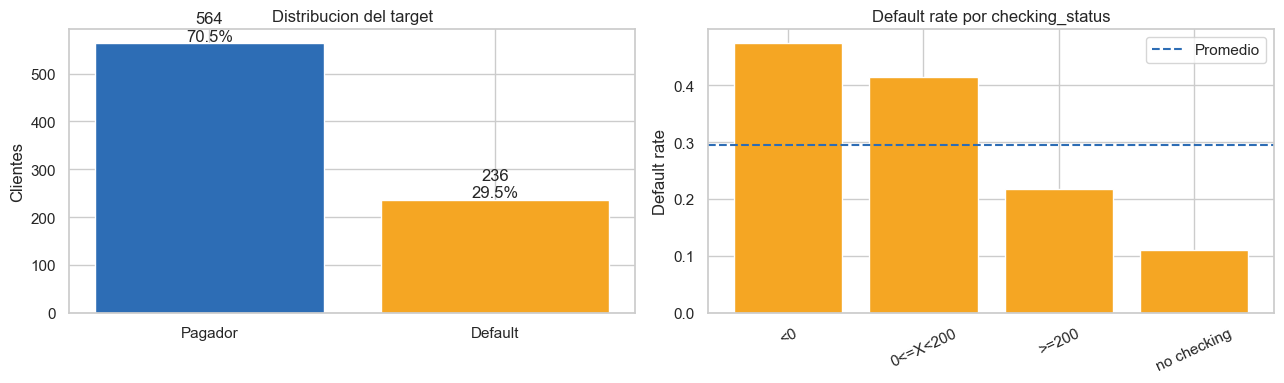

Figura guardada: reports\figures\notebook_eda_target_checking.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

target_counts = df_train["default_90d"].value_counts().sort_index()
axes[0].bar(["Pagador", "Default"], target_counts.values, color=["#2D6DB5", "#F5A623"])
axes[0].set_title("Distribucion del target")
axes[0].set_ylabel("Clientes")
for idx, value in enumerate(target_counts.values):
    axes[0].text(idx, value + 5, f"{value}\n{value/len(df_train):.1%}", ha="center")

check_rate = eda_tables["checking_status"]["default_rate"].sort_values(ascending=False)
axes[1].bar(check_rate.index.astype(str), check_rate.values, color="#F5A623")
axes[1].axhline(df_train["default_90d"].mean(), color="#2D6DB5", linestyle="--", label="Promedio")
axes[1].set_title("Default rate por checking_status")
axes[1].set_ylabel("Default rate")
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend()

plt.tight_layout()
fig_path = FIG_DIR / "notebook_eda_target_checking.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada:", fig_path)

## 3. Feature engineering reproducible

In [5]:
df_model = flow.build_model_frame(df_train)
df_test_model = flow.build_model_frame(df_test)

feature_cols = [
    col for col in df_model.columns
    if col not in {"id_cliente", "default_90d", "target", "id_adicional", "Probabilidad"}
]
numeric_cols, categorical_cols = flow.split_feature_types(df_model, feature_cols)

feature_summary = pd.DataFrame({
    "tipo": ["features_totales", "numericas", "categoricas"],
    "cantidad": [len(feature_cols), len(numeric_cols), len(categorical_cols)]
})
display(feature_summary)

print("Ejemplos de features creadas:")
created_features = [c for c in build_features_german(df_train).columns if c not in df_train.columns]
display(pd.DataFrame({"feature_creada": created_features[:25]}))

,tipo,cantidad
0,features_totales,62
1,numericas,49
2,categoricas,13


Ejemplos de features creadas:


,feature_creada
0,duration_largo
1,duration_corto
2,log_duration
3,log_credit_amount
4,monto_alto
5,monto_bajo
6,carga_financiera
7,log_carga
8,cuota_estimada
9,log_cuota


## 4. Split anti-leakage y comparacion de modelos

In [6]:
from sklearn.model_selection import train_test_split

X = df_model[feature_cols]
y = df_model["default_90d"]
X_submission = df_test_model.reindex(columns=feature_cols)

x_train_full, x_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.25, stratify=y_train_full, random_state=42
)

split_table = pd.DataFrame({
    "split": ["train", "validacion", "test_interno"],
    "filas": [len(x_train), len(x_val), len(x_test)],
    "default_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
})
display(split_table)

preprocessor = flow.make_preprocessor(numeric_cols, categorical_cols)

rows = []
fitted_models = {}
for name, estimator in flow.make_candidates().items():
    model = flow.fit_candidate(name, estimator, preprocessor, x_train, y_train)
    metrics = flow.evaluate_classifier(name, model, x_train, y_train, x_val, y_val)
    overfit_penalty = max(metrics["gap_train_val"] - 0.06, 0) * 0.45
    brier_penalty = metrics["brier_val"] * 0.04
    metrics["selection_score"] = round(metrics["auc_val"] - overfit_penalty - brier_penalty, 5)
    rows.append(metrics)
    fitted_models[name] = model

comparison = pd.DataFrame(rows).sort_values("selection_score", ascending=False)
comparison.to_csv("reports/model_comparison_orquestador.csv", index=False)
display(comparison)

champion_name = comparison.iloc[0]["model"]
champion_val = fitted_models[champion_name]
print("Modelo campeon operativo:", champion_name)

,split,filas,default_rate
0,train,480,0.2958
1,validacion,160,0.2938
2,test_interno,160,0.2938


,model,auc_train,auc_val,gini_val,ks_val,pr_auc_val,brier_val,lift10_val,f1_050,recall_050,precision_050,gap_train_val,selection_score
2,LogReg_balanced_C01,0.8647,0.8021,0.6042,0.5272,0.6056,0.1704,2.1300,0.6545,0.7660,0.5714,0.0626,0.7941
3,RandomForest_stable,0.9244,0.8123,0.6246,0.5609,0.6943,0.1619,3.1900,0.5800,0.6170,0.5472,0.1121,0.7824
6,GradientBoosting_shallow,0.9326,0.8063,0.6125,0.5590,0.6334,0.1678,2.5500,0.6111,0.7021,0.5410,0.1264,0.7697
4,ExtraTrees_stable,0.9206,0.7987,0.5974,0.4988,0.6482,0.1737,2.3400,0.5766,0.6809,0.5000,0.1218,0.7639
1,LogReg_balanced_C03,0.8752,0.7814,0.5628,0.5022,0.5552,0.1816,2.3400,0.6250,0.7447,0.5385,0.0938,0.7589
5,HistGradientBoosting,1.0000,0.8004,0.6008,0.4897,0.6046,0.1655,2.5500,0.6186,0.6383,0.6000,0.1996,0.7310
0,Dummy_baseline,0.5000,0.5000,0.0000,0.1407,0.6469,0.2075,1.2800,0.0000,0.0000,0.0000,0.0000,0.4917


Modelo campeon operativo: LogReg_balanced_C01


## 5. Validacion del campeon

El campeon se selecciona por un criterio auditor, no solo por AUC bruto. Penalizamos sobreajuste y mala calibracion porque el caso exige probabilidades utilizables para aprobar o rechazar creditos.


In [7]:
test_metrics = flow.evaluate_classifier(champion_name, champion_val, x_train, y_train, x_test, y_test)
display(pd.DataFrame([test_metrics]))

y_val_proba = champion_val.predict_proba(x_val)[:, 1]
threshold_grid = flow.optimize_binary_threshold(y_val, y_val_proba)
threshold_grid.to_csv("reports/threshold_analysis_orquestador.csv", index=False)
best_threshold = threshold_grid.iloc[0].to_dict()

policy, policy_grid = flow.three_band_policy(y_val, y_val_proba)
policy_grid.to_csv("reports/politica_3_bandas_grid_orquestador.csv", index=False)
pd.DataFrame([policy]).to_csv("reports/politica_3_bandas_orquestador.csv", index=False)

print("Mejor threshold binario por ROI:", best_threshold["threshold"])
display(pd.DataFrame([best_threshold]))
display(pd.DataFrame([policy]))

,model,auc_train,auc_val,gini_val,ks_val,pr_auc_val,brier_val,lift10_val,f1_050,recall_050,precision_050,gap_train_val
0,LogReg_balanced_C01,0.8647,0.7051,0.4103,0.3589,0.5107,0.2157,2.1300,0.5088,0.6170,0.4328,0.1596


Mejor threshold binario por ROI: 0.36


,threshold,good_approved,good_rejected,bad_approved,bad_rejected,benefit_usd,base_benefit_usd,incremental_saving_usd,roi_vs_base,recall_default,approval_rate
0,0.3600,74.0000,39.0000,6.0000,41.0000,9450.0000,-90150.0000,99600.0000,1.1048,0.8723,0.5000


,u_bajo,u_alto,beneficio_3_bandas_usd,clientes_bajo,clientes_medio,clientes_alto,pct_bajo,pct_medio,pct_alto,tasa_default_bajo,tasa_default_medio,tasa_default_alto,decision_bajo,decision_medio,decision_alto,nota
0,0.3000,0.3600,9150.0000,71.0000,9.0000,80.0000,44.3800,5.6200,50.0000,0.0704,0.1111,0.5125,APROBAR linea completa,CONDICIONAR linea al 50% o revision manual,RECHAZAR o exigir mitigantes,Politica optimizada en validacion; valores eco...


## 6. Politica de riesgo recomendada

,banda,rango_prob_default,default_observado_validacion,decision
0,Bajo,< 0.30,0.0704,APROBAR linea completa
1,Medio,0.30 - 0.36,0.1111,CONDICIONAR linea al 50% o revision manual
2,Alto,>= 0.36,0.5125,RECHAZAR o exigir mitigantes


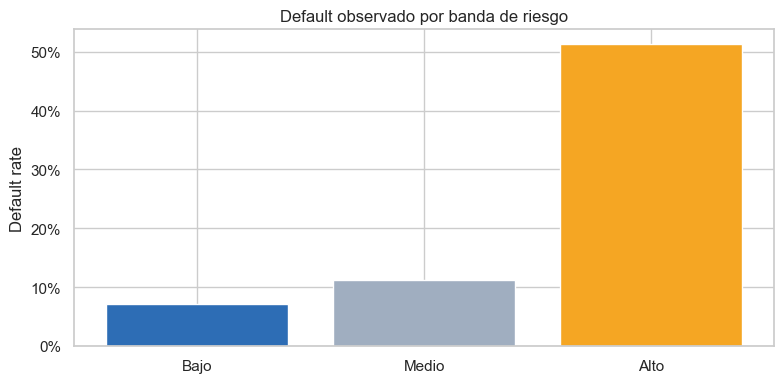

Figura guardada: reports\figures\notebook_politica_bandas.png


In [8]:
policy_table = pd.DataFrame([
    {
        "banda": "Bajo",
        "rango_prob_default": f"< {policy['u_bajo']:.2f}",
        "default_observado_validacion": policy["tasa_default_bajo"],
        "decision": policy["decision_bajo"],
    },
    {
        "banda": "Medio",
        "rango_prob_default": f"{policy['u_bajo']:.2f} - {policy['u_alto']:.2f}",
        "default_observado_validacion": policy["tasa_default_medio"],
        "decision": policy["decision_medio"],
    },
    {
        "banda": "Alto",
        "rango_prob_default": f">= {policy['u_alto']:.2f}",
        "default_observado_validacion": policy["tasa_default_alto"],
        "decision": policy["decision_alto"],
    },
])
display(policy_table)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(policy_table["banda"], policy_table["default_observado_validacion"], color=["#2D6DB5", "#A0AEC0", "#F5A623"])
ax.set_title("Default observado por banda de riesgo")
ax.set_ylabel("Default rate")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
fig_path = FIG_DIR / "notebook_politica_bandas.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada:", fig_path)

## 7. Entrenamiento final, artefacto de scoring y submission

In [9]:
selected_estimator = deepcopy(flow.make_candidates()[champion_name])
final_model = flow.fit_candidate(champion_name, selected_estimator, preprocessor, X, y)

submission_proba = final_model.predict_proba(X_submission)[:, 1]
submission = pd.DataFrame({
    "id_cliente": df_test["id_cliente"].values,
    "prob_default": submission_proba,
})

assert len(submission) == len(df_test)
assert submission["id_cliente"].is_unique
assert submission["prob_default"].between(0, 1).all()

submission.to_csv("submission.csv", index=False)

artifact = {
    "model": final_model,
    "model_name": champion_name,
    "feature_columns": feature_cols,
    "numeric_columns": numeric_cols,
    "categorical_columns": categorical_cols,
    "target_col": "default_90d",
    "target_mapping": {"good": 0, "bad": 1},
    "policy": {
        "u_bajo": float(policy["u_bajo"]),
        "u_alto": float(policy["u_alto"]),
        "decision_bajo": policy["decision_bajo"],
        "decision_medio": policy["decision_medio"],
        "decision_alto": policy["decision_alto"],
    },
    "business_values": {
        "good_approved": flow.GOOD_APPROVED,
        "good_rejected": flow.GOOD_REJECTED,
        "bad_approved": flow.BAD_APPROVED,
        "bad_rejected": flow.BAD_REJECTED,
        "medium_exposure_factor": flow.MEDIUM_EXPOSURE_FACTOR,
    },
}
joblib.dump(artifact, "models/scoring_tool.joblib")

report = {
    "status": "READY",
    "champion_model": champion_name,
    "validation_metrics": comparison.iloc[0].to_dict(),
    "internal_test_metrics": test_metrics,
    "best_binary_threshold": best_threshold,
    "three_band_policy": policy,
    "submission": {
        "path": "submission.csv",
        "rows": int(len(submission)),
        "prob_min": round(float(submission["prob_default"].min()), 6),
        "prob_mean": round(float(submission["prob_default"].mean()), 6),
        "prob_max": round(float(submission["prob_default"].max()), 6),
    },
}
with open("reports/scoring_tool_report.json", "w", encoding="utf-8") as file:
    json.dump(report, file, indent=2, ensure_ascii=False, default=str)

print("submission.csv generado y validado")
display(submission.head())
display(pd.DataFrame([report["submission"]]))

submission.csv generado y validado

,id_cliente,prob_default
0,442,0.6438
1,814,0.7276
2,607,0.1291
3,567,0.5497
4,688,0.8075


,path,rows,prob_min,prob_mean,prob_max
0,submission.csv,200,0.0169,0.4481,0.9694


## 8. Herramienta de scoring: prueba con solicitud individual

In [10]:
solicitud_demo = {
    "id_cliente": 100001,
    "checking_status": "<0",
    "duration": 36,
    "credit_history": "all paid",
    "purpose": "new car",
    "credit_amount": 6500,
    "savings_status": "<100",
    "employment": "<1",
    "installment_commitment": 4,
    "personal_status": "male single",
    "other_parties": "none",
    "residence_since": 2,
    "property_magnitude": "car",
    "age": 28,
    "other_payment_plans": "none",
    "housing": "rent",
    "existing_credits": 2,
    "job": "skilled",
    "num_dependents": 1,
    "own_telephone": "none",
    "foreign_worker": "yes",
}

scoring_result = score_app(pd.DataFrame([solicitud_demo]), artifact)
display(scoring_result)

,id_cliente,prob_default,banda_riesgo,decision_politica,factores_alerta
0,100001,0.9801,Alto,RECHAZAR o exigir mitigantes,liquidez_debil;historial_crediticio_riesgoso;b...


## 9. Galería de figuras listas para PPT

Esta sección deja dentro del notebook las figuras recomendadas para la presentación. También guarda cada imagen en `reports/figures/` para poder insertarla directamente en PowerPoint.

Uso sugerido:

- Slide datos/EDA: target + `checking_status`.
- Slide modelo: comparación de modelos.
- Slide interpretabilidad: coeficientes del modelo campeón.
- Slide desempeño: curvas ROC y Precision-Recall.
- Slide negocio: ROI por umbral.
- Slide política: 3 bandas de riesgo.
- Slide herramienta: ejemplo de scoring individual.


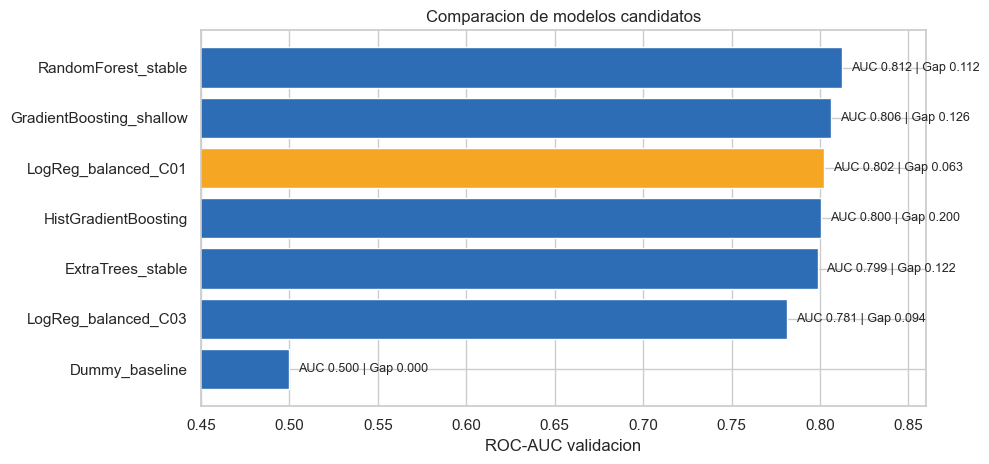

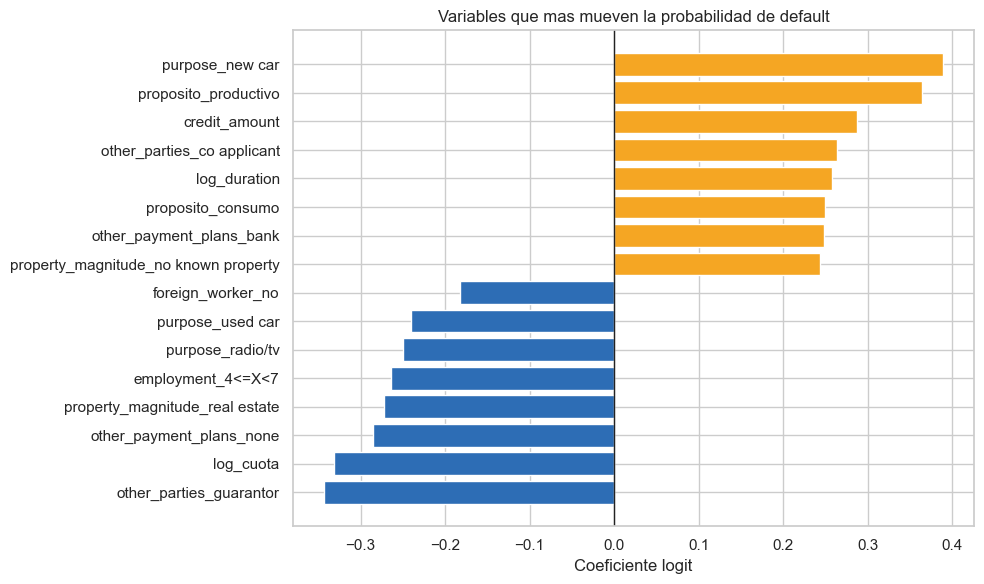

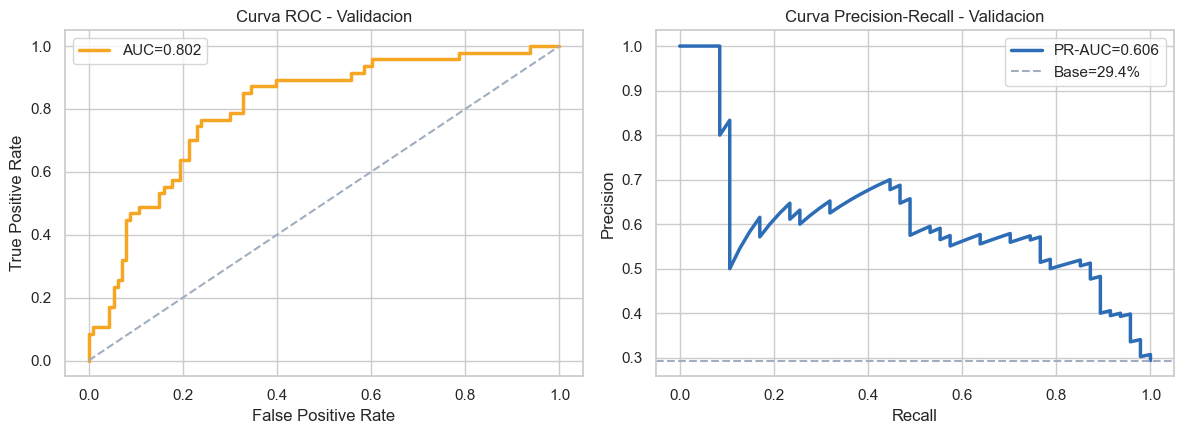

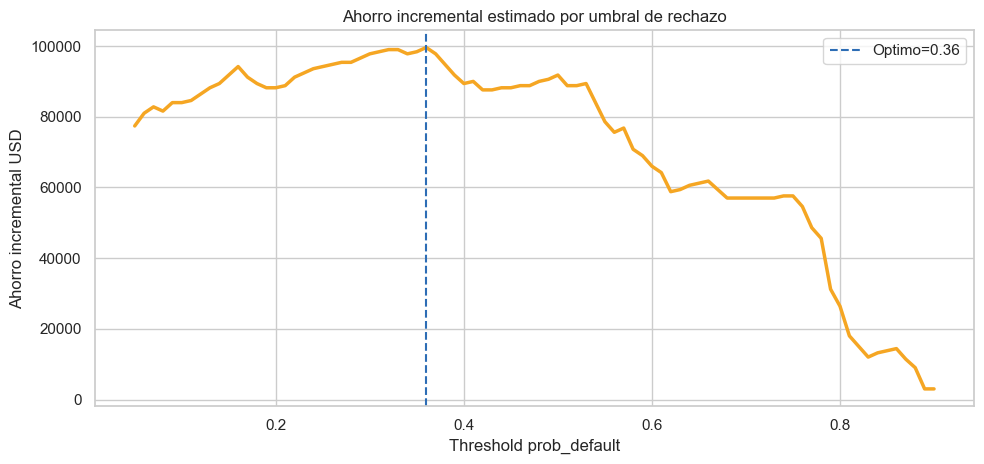

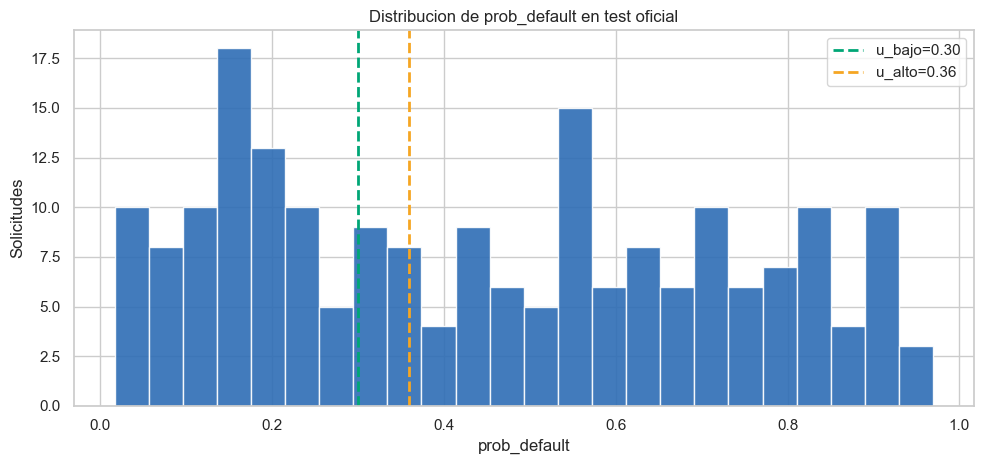

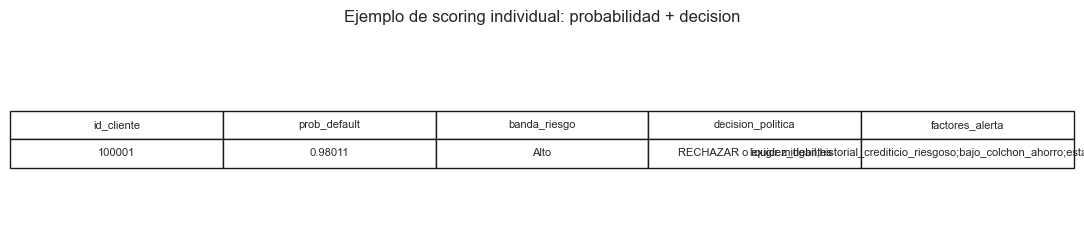

,slide_sugerida,titulo,archivo
0,Slide 3-4: Datos y hallazgos EDA,Distribucion del target y default rate por che...,reports\figures\notebook_eda_target_checking.png
1,Slide 6: Estrategia de modelado,Comparacion de modelos y seleccion auditora,reports\figures\ppt_02_comparacion_modelos.png
2,Slide 5-7: Variables importantes,Interpretabilidad del modelo campeon,reports\figures\ppt_03_interpretabilidad_coefi...
3,Slide 7: Resultados tecnicos,Curvas ROC y Precision-Recall,reports\figures\ppt_04_curvas_desempeno.png
4,Slide 9: Impacto financiero,ROI financiero por threshold,reports\figures\ppt_05_roi_threshold.png
5,Slide 8: Politica de 3 bandas,Default observado por banda de riesgo,reports\figures\notebook_politica_bandas.png
6,Slide 8-10: Implementacion,Distribucion de scores en test oficial,reports\figures\ppt_07_distribucion_scores_tes...
7,Slide 10: Recomendacion final,Ejemplo de herramienta de scoring,reports\figures\ppt_08_ejemplo_herramienta_sco...



Slide 3-4: Datos y hallazgos EDA | Distribucion del target y default rate por checking_status | reports\figures\notebook_eda_target_checking.png


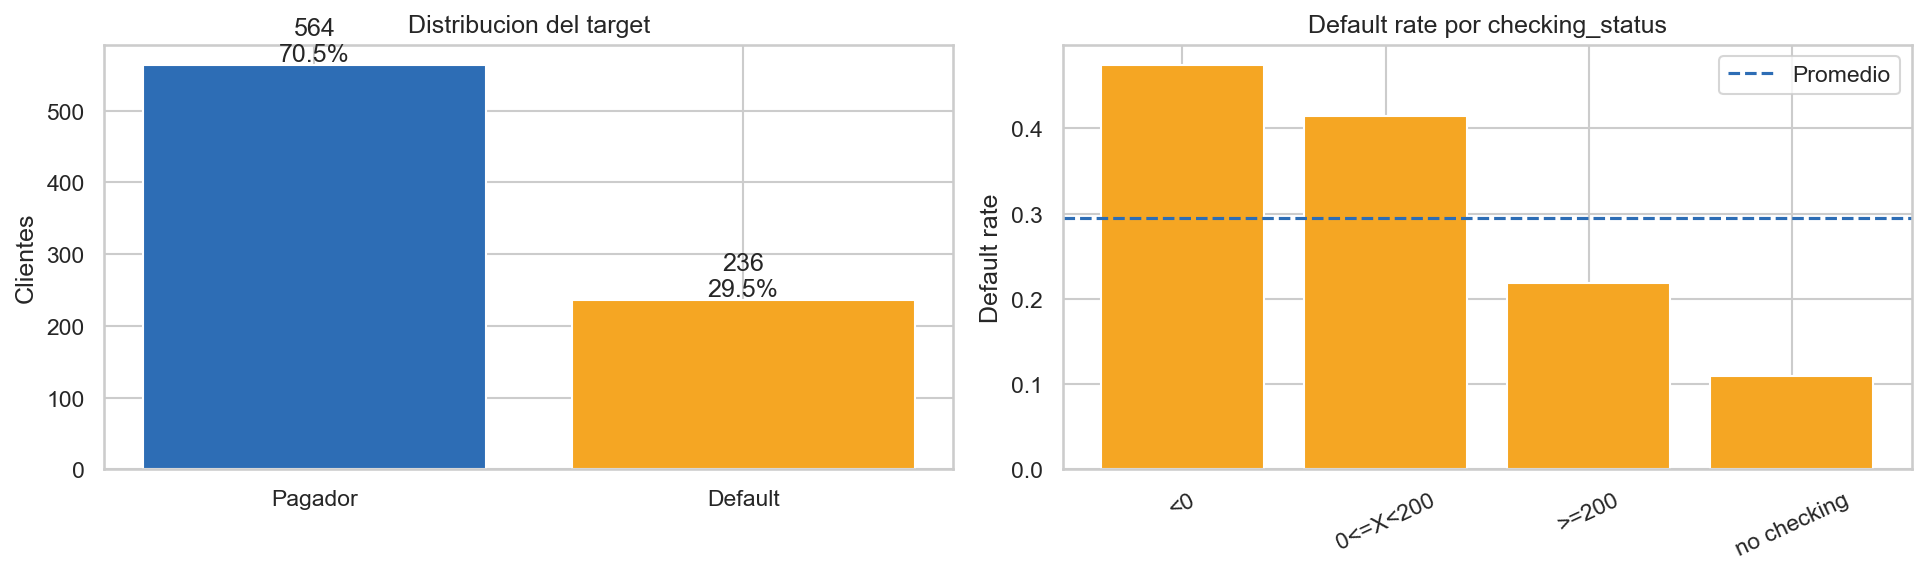


Slide 6: Estrategia de modelado | Comparacion de modelos y seleccion auditora | reports\figures\ppt_02_comparacion_modelos.png


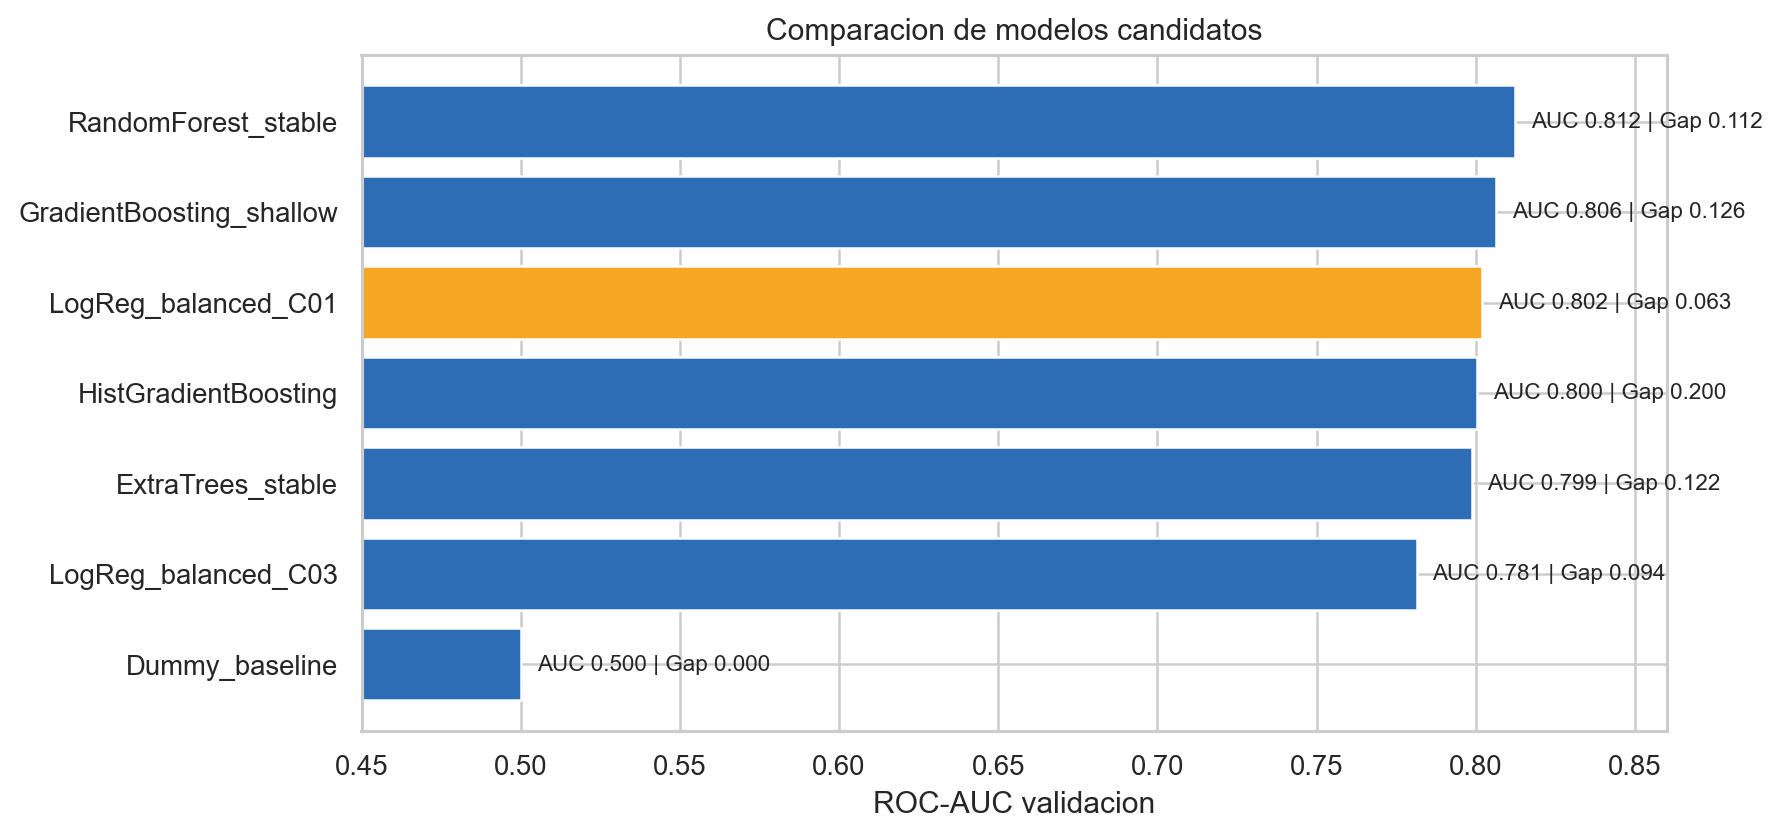


Slide 5-7: Variables importantes | Interpretabilidad del modelo campeon | reports\figures\ppt_03_interpretabilidad_coeficientes.png


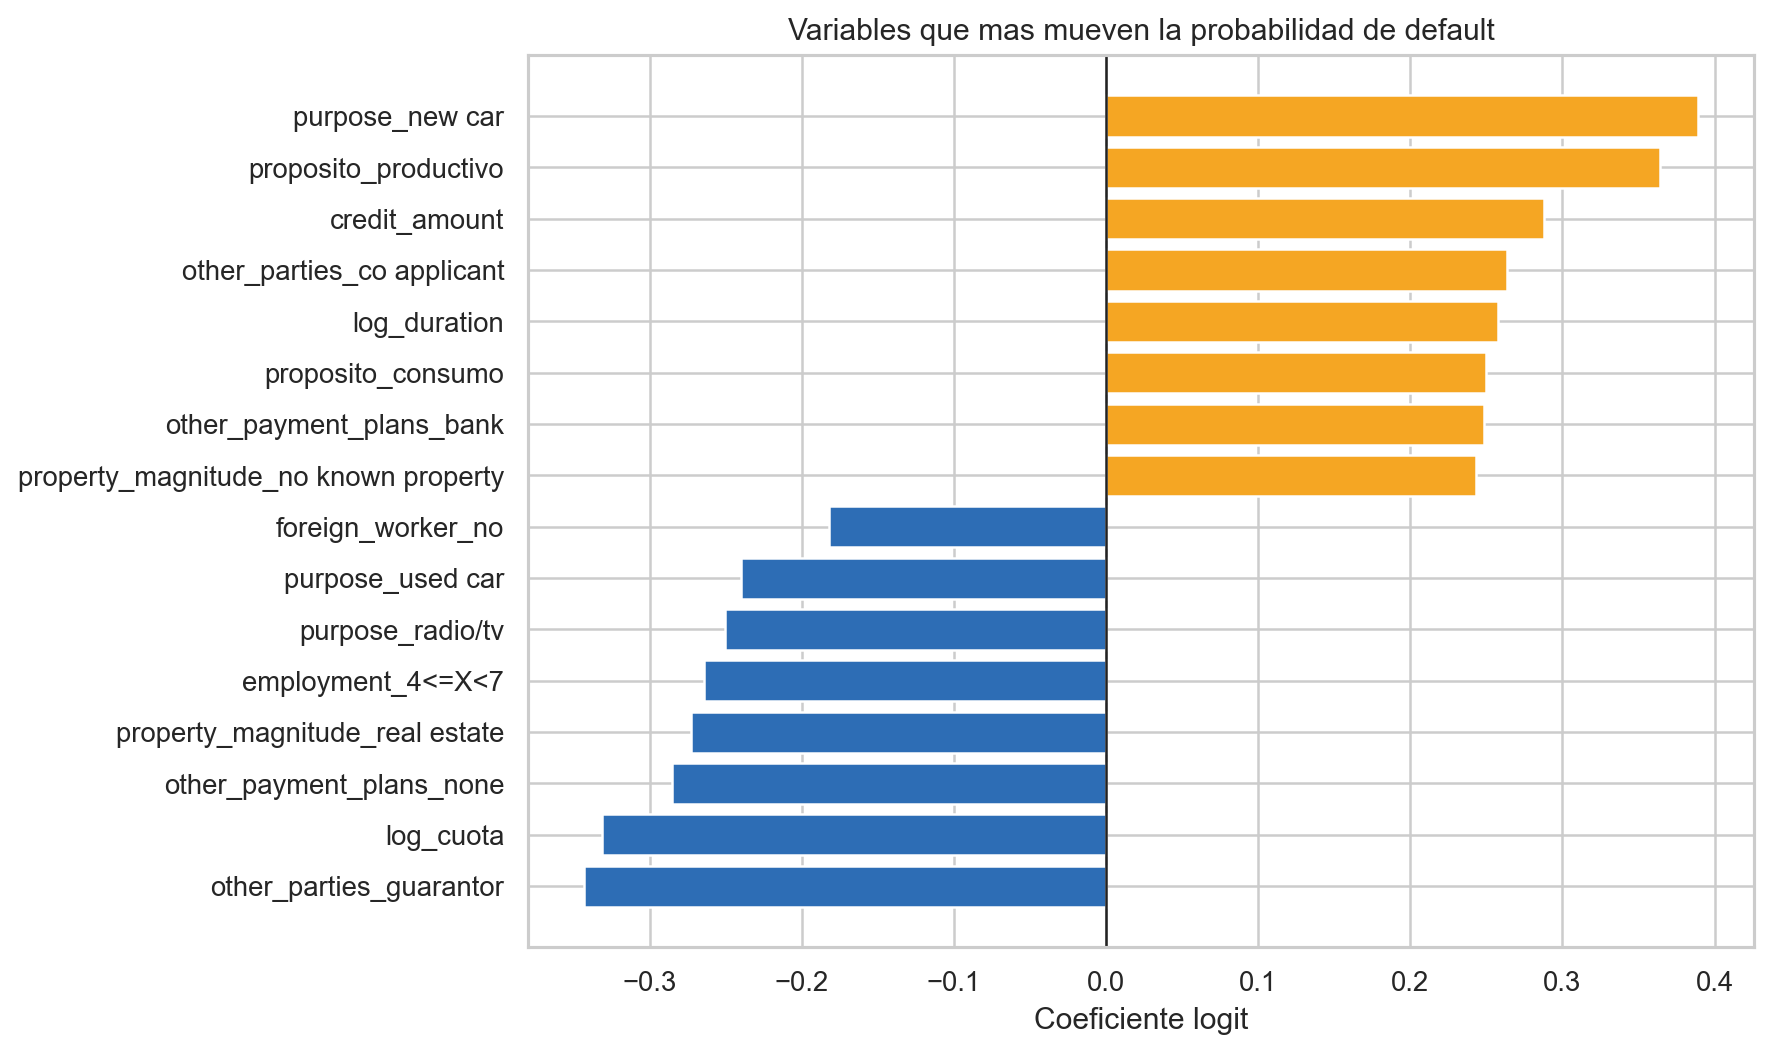


Slide 7: Resultados tecnicos | Curvas ROC y Precision-Recall | reports\figures\ppt_04_curvas_desempeno.png


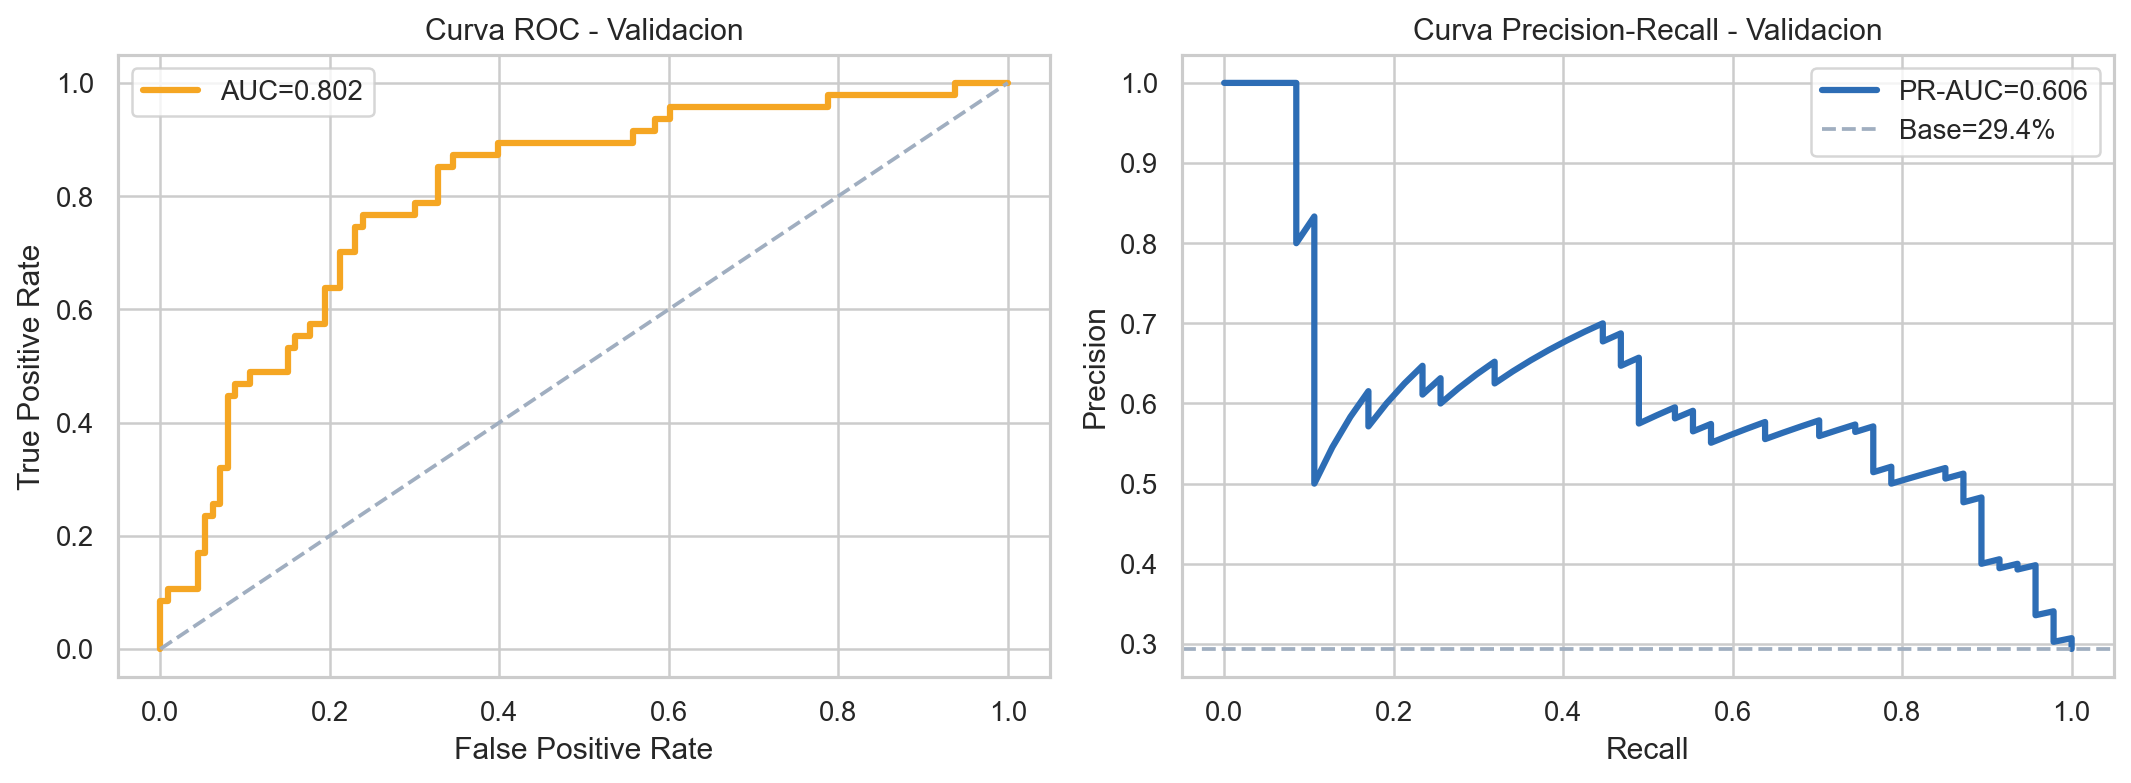


Slide 9: Impacto financiero | ROI financiero por threshold | reports\figures\ppt_05_roi_threshold.png


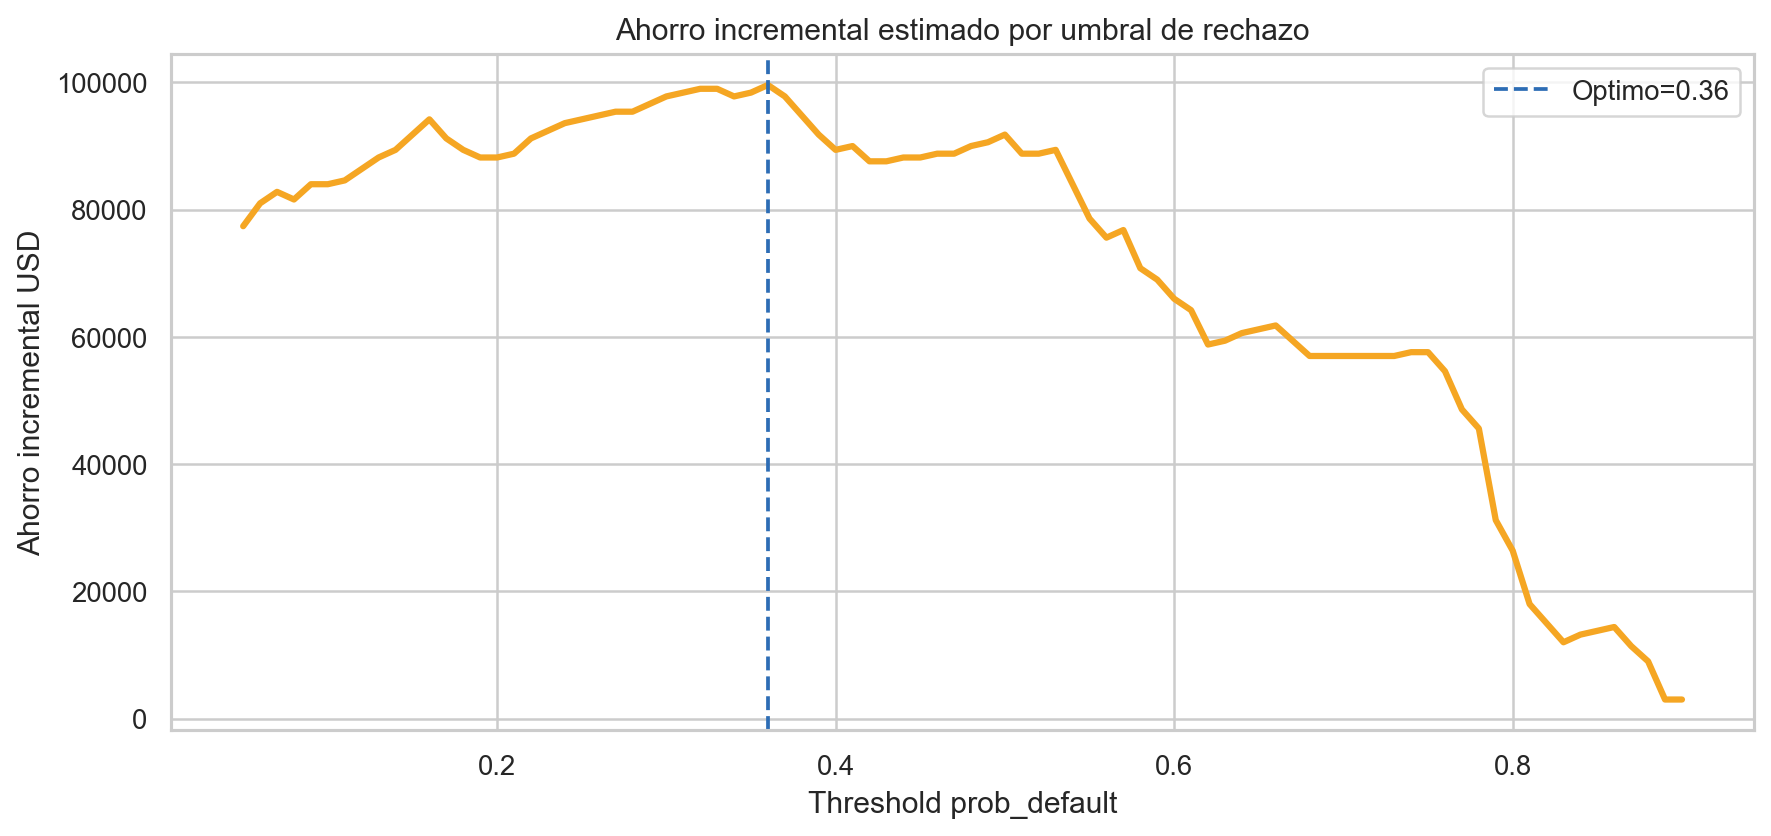


Slide 8: Politica de 3 bandas | Default observado por banda de riesgo | reports\figures\notebook_politica_bandas.png


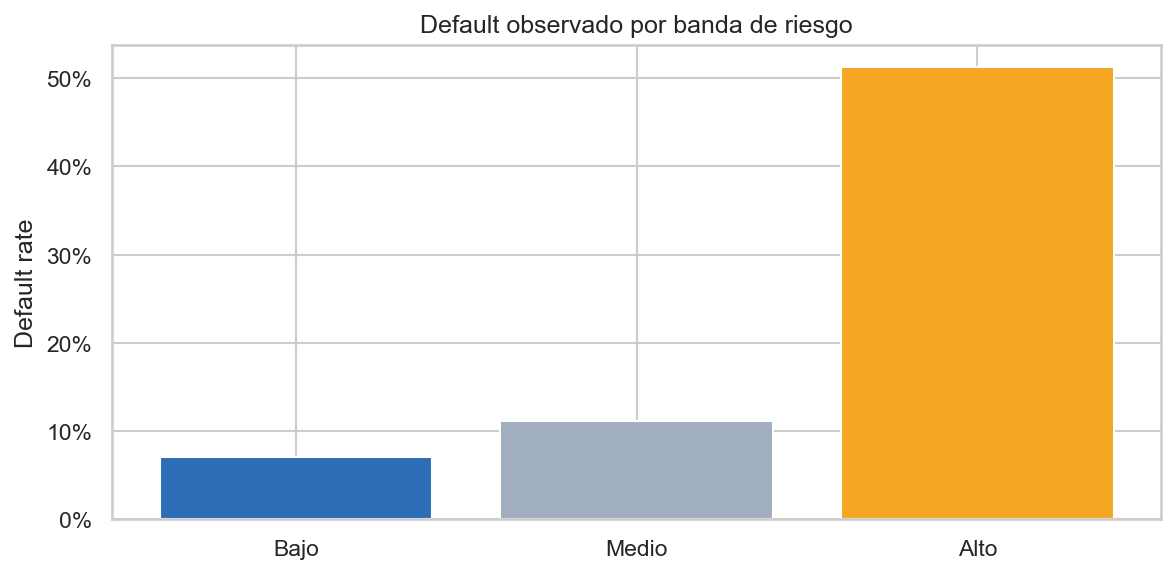


Slide 8-10: Implementacion | Distribucion de scores en test oficial | reports\figures\ppt_07_distribucion_scores_test.png


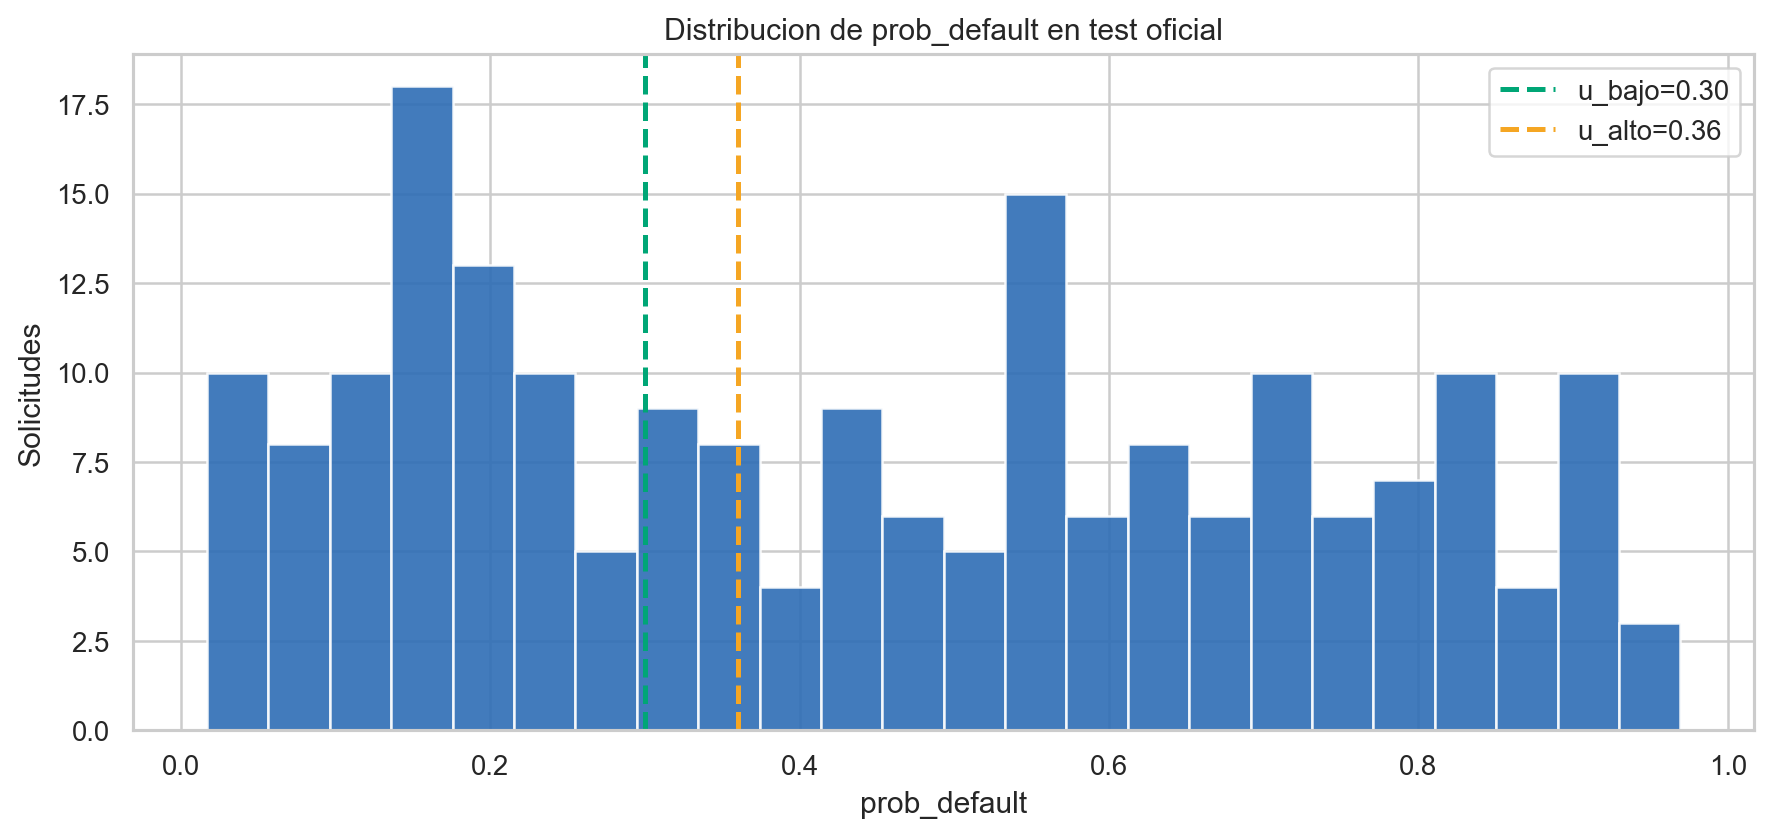


Slide 10: Recomendacion final | Ejemplo de herramienta de scoring | reports\figures\ppt_08_ejemplo_herramienta_scoring.png


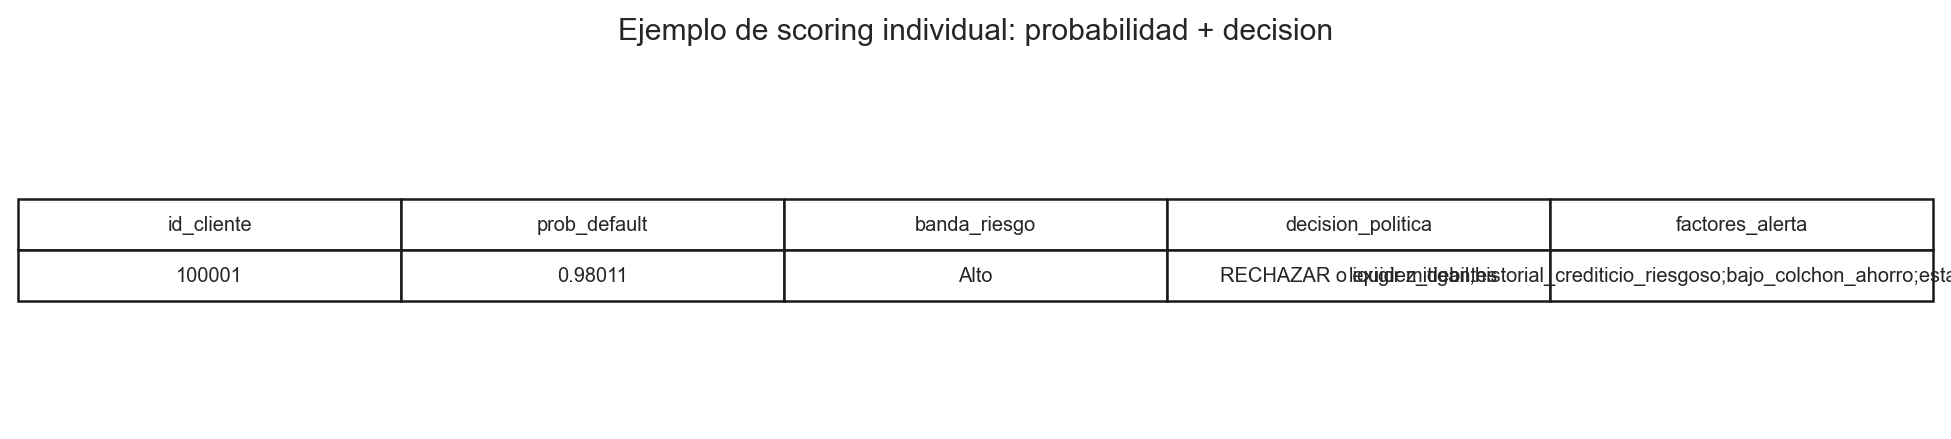

In [11]:
from sklearn.metrics import auc as sk_auc
from sklearn.metrics import precision_recall_curve, roc_curve

ppt_figures = []

def register_figure(path, title, slide):
    ppt_figures.append({"slide_sugerida": slide, "titulo": title, "archivo": str(path)})

# Figura 1: EDA target + checking_status ya creada en la seccion 2
register_figure(
    FIG_DIR / "notebook_eda_target_checking.png",
    "Distribucion del target y default rate por checking_status",
    "Slide 3-4: Datos y hallazgos EDA",
)

# Figura 2: comparacion de modelos
fig, ax = plt.subplots(figsize=(10, 4.8))
plot_df = comparison.sort_values("auc_val", ascending=True).copy()
colors = ["#F5A623" if m == champion_name else "#2D6DB5" for m in plot_df["model"]]
ax.barh(plot_df["model"], plot_df["auc_val"], color=colors)
ax.set_xlim(0.45, max(0.86, plot_df["auc_val"].max() + 0.03))
ax.set_xlabel("ROC-AUC validacion")
ax.set_title("Comparacion de modelos candidatos")
for idx, row in enumerate(plot_df.itertuples()):
    ax.text(row.auc_val + 0.005, idx, f"AUC {row.auc_val:.3f} | Gap {row.gap_train_val:.3f}", va="center", fontsize=9)
plt.tight_layout()
path = FIG_DIR / "ppt_02_comparacion_modelos.png"
plt.savefig(path, dpi=180, bbox_inches="tight")
plt.show()
register_figure(path, "Comparacion de modelos y seleccion auditora", "Slide 6: Estrategia de modelado")

# Figura 3: interpretabilidad por coeficientes del modelo campeon
try:
    model_step = final_model.named_steps["model"]
    prep_step = final_model.named_steps["preprocessor"]
    feature_names = prep_step.get_feature_names_out()
    coefs = pd.Series(model_step.coef_[0], index=feature_names).sort_values()
    top_negative = coefs.head(8)
    top_positive = coefs.tail(8)
    coef_plot = pd.concat([top_negative, top_positive])

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ["#2D6DB5" if v < 0 else "#F5A623" for v in coef_plot.values]
    labels = [x.replace("num__", "").replace("cat__", "").replace("onehot__", "")[-55:] for x in coef_plot.index]
    ax.barh(labels, coef_plot.values, color=colors)
    ax.axvline(0, color="#222222", linewidth=1)
    ax.set_title("Variables que mas mueven la probabilidad de default")
    ax.set_xlabel("Coeficiente logit")
    plt.tight_layout()
    path = FIG_DIR / "ppt_03_interpretabilidad_coeficientes.png"
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    register_figure(path, "Interpretabilidad del modelo campeon", "Slide 5-7: Variables importantes")
except Exception as exc:
    print("No se pudo generar figura de coeficientes:", exc)

# Figura 4: curvas ROC y PR
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
prec, rec, _ = precision_recall_curve(y_val, y_val_proba)
roc_auc = sk_auc(fpr, tpr)
pr_auc = sk_auc(rec, prec)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fpr, tpr, color="#F5A623", linewidth=2.5, label=f"AUC={roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="#A0AEC0")
axes[0].set_title("Curva ROC - Validacion")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].plot(rec, prec, color="#2D6DB5", linewidth=2.5, label=f"PR-AUC={pr_auc:.3f}")
axes[1].axhline(y_val.mean(), linestyle="--", color="#A0AEC0", label=f"Base={y_val.mean():.1%}")
axes[1].set_title("Curva Precision-Recall - Validacion")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
plt.tight_layout()
path = FIG_DIR / "ppt_04_curvas_desempeno.png"
plt.savefig(path, dpi=180, bbox_inches="tight")
plt.show()
register_figure(path, "Curvas ROC y Precision-Recall", "Slide 7: Resultados tecnicos")

# Figura 5: ROI por threshold
roi_plot = threshold_grid.sort_values("threshold")
fig, ax1 = plt.subplots(figsize=(10, 4.8))
ax1.plot(roi_plot["threshold"], roi_plot["incremental_saving_usd"], color="#F5A623", linewidth=2.5)
ax1.axvline(best_threshold["threshold"], color="#2D6DB5", linestyle="--", label=f"Optimo={best_threshold['threshold']:.2f}")
ax1.set_title("Ahorro incremental estimado por umbral de rechazo")
ax1.set_xlabel("Threshold prob_default")
ax1.set_ylabel("Ahorro incremental USD")
ax1.legend(loc="upper right")
plt.tight_layout()
path = FIG_DIR / "ppt_05_roi_threshold.png"
plt.savefig(path, dpi=180, bbox_inches="tight")
plt.show()
register_figure(path, "ROI financiero por threshold", "Slide 9: Impacto financiero")

# Figura 6: politica de bandas
register_figure(
    FIG_DIR / "notebook_politica_bandas.png",
    "Default observado por banda de riesgo",
    "Slide 8: Politica de 3 bandas",
)

# Figura 7: distribucion de scores en el test oficial
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.hist(submission["prob_default"], bins=24, color="#2D6DB5", edgecolor="white", alpha=0.9)
ax.axvline(policy["u_bajo"], color="#00A676", linestyle="--", linewidth=2, label=f"u_bajo={policy['u_bajo']:.2f}")
ax.axvline(policy["u_alto"], color="#F5A623", linestyle="--", linewidth=2, label=f"u_alto={policy['u_alto']:.2f}")
ax.set_title("Distribucion de prob_default en test oficial")
ax.set_xlabel("prob_default")
ax.set_ylabel("Solicitudes")
ax.legend()
plt.tight_layout()
path = FIG_DIR / "ppt_07_distribucion_scores_test.png"
plt.savefig(path, dpi=180, bbox_inches="tight")
plt.show()
register_figure(path, "Distribucion de scores en test oficial", "Slide 8-10: Implementacion")

# Figura 8: ejemplo de herramienta de scoring
fig, ax = plt.subplots(figsize=(11, 2.6))
ax.axis("off")
demo_table = scoring_result[["id_cliente", "prob_default", "banda_riesgo", "decision_politica", "factores_alerta"]].copy()
table = ax.table(
    cellText=demo_table.values,
    colLabels=demo_table.columns,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.8)
ax.set_title("Ejemplo de scoring individual: probabilidad + decision", pad=16)
plt.tight_layout()
path = FIG_DIR / "ppt_08_ejemplo_herramienta_scoring.png"
plt.savefig(path, dpi=180, bbox_inches="tight")
plt.show()
register_figure(path, "Ejemplo de herramienta de scoring", "Slide 10: Recomendacion final")

figures_table = pd.DataFrame(ppt_figures)
figures_table.to_csv("reports/figuras_para_ppt.csv", index=False)
display(figures_table)

for item in ppt_figures:
    print(f"\n{item['slide_sugerida']} | {item['titulo']} | {item['archivo']}")
    display(Image(filename=item["archivo"], width=900))

## 10. Conclusiones ejecutivas

1. El modelo final estima `prob_default` para cada solicitante y genera una salida directamente accionable.
2. La politica de 3 bandas transforma el score en decisiones: aprobar, condicionar o rechazar.
3. La seleccion del modelo prioriza estabilidad, interpretabilidad y probabilidad defendible, no solo AUC bruto.
4. La herramienta generada (`models/scoring_tool.joblib`) puede operar sobre una solicitud individual o sobre lotes completos.
5. El `submission.csv` queda listo con 200 filas y columnas `id_cliente`, `prob_default`.

**Recomendacion para FinanCrece:** implementar este score como primera version de motor de originacion, con monitoreo mensual de drift, default real por banda y recalibracion cuando se acumule nueva data.
